# Feature Importance Analysis

Loads a trained ML model and answers three questions:

1. **Per-bottleneck** — which features drive each classifier?
2. **Global** — which features are most / least important across all classifiers?
3. **By statistic** — which tsfresh statistic *types* (mean, skewness, autocorrelation, …) matter most?

**How to use**
1. Set `MODEL_PATH` in the Config cell below.
2. Run all cells (`Kernel → Restart & Run All`).
3. Results are saved to `RESULTS_DIR` — previous runs are preserved.

In [21]:
# ── CONFIG — edit these ──────────────────────────────────────────────────────
MODEL_PATH  = "models/default.pkl"                      # relative to repo root
TOP_N       = 20                                         # features shown in plots
SAVE_N      = 5                                          # top/bottom N saved per run
RESULTS_DIR = "models/"    # saved results directory
# ─────────────────────────────────────────────────────────────────────────────

In [22]:
import sys
import json
import math
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Walk up until we find the repo root (contains 'src/')
_repo_root = Path.cwd()
for _ in range(6):
    if (_repo_root / "src").exists():
        break
    _repo_root = _repo_root.parent
else:
    raise RuntimeError("Could not locate repo root — run from inside the project.")

sys.path.insert(0, str(_repo_root / "src"))

MODEL_PATH_ABS  = _repo_root / MODEL_PATH
RESULTS_DIR_ABS = _repo_root / RESULTS_DIR

from hpc_bottleneck_detector.ml.backends.default_backend import DefaultBackend

print(f"Repo root : {_repo_root}")
print(f"Model     : {MODEL_PATH_ABS}")
print(f"Results   : {RESULTS_DIR_ABS}")

Repo root : /home/crippius/uni/master-thesis/hpc-bottleneck-detector
Model     : /home/crippius/uni/master-thesis/hpc-bottleneck-detector/models/default.pkl
Results   : /home/crippius/uni/master-thesis/hpc-bottleneck-detector/models


## 1. Load Model

In [23]:
backend    = DefaultBackend.load(str(MODEL_PATH_ABS))
model_name = MODEL_PATH_ABS.stem

print(f"Model: {model_name}")
print(f"\nBottleneck types ({len(backend._models)}):")
for bt_name in backend._models:
    n_feat = len(backend._feature_cols[bt_name])
    print(f"  {bt_name:<45} {n_feat:>4} features")

Model: default

Bottleneck types (6):
  PIPELINE_STALL                                 484 features
  COMPUTE_UNDERUTILIZATION                       820 features
  PRECISION_WASTE                                693 features
  BRANCH_MISPREDICTION                           231 features
  CACHE_PRESSURE                                 884 features
  INTRA_NODE_LOAD_IMBALANCE                      664 features


## 2. Per-Bottleneck Feature Importance

Top and bottom `TOP_N` features for each bottleneck type, ranked by RandomForest `feature_importances_`.

In [24]:
importance_by_bt: dict[str, pd.DataFrame] = {}
for bt_name, clf in backend._models.items():
    df = (
        pd.DataFrame({
            "feature"   : backend._feature_cols[bt_name],
            "importance": clf.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    importance_by_bt[bt_name] = df

for bt_name, df in importance_by_bt.items():
    n = len(df)
    print(f"\n{'─'*62}")
    print(f"  {bt_name}  ({n} features selected)")
    print(f"{'─'*62}")
    print(f"  Top {min(TOP_N, n)}:")
    print(df.head(TOP_N).to_string(index=True))
    if n > TOP_N * 2:
        print(f"  ... ({n - TOP_N * 2} features omitted) ...")
    print(f"  Bottom {min(TOP_N, n)}:")
    print(df.tail(TOP_N).to_string(index=True))


──────────────────────────────────────────────────────────────
  PIPELINE_STALL  (484 features selected)
──────────────────────────────────────────────────────────────
  Top 20:
                                                                                 feature  importance
0                                                          cpu_CPI_CPI__quantile__q_0.05    0.054642
1                                                          cpu_CPI_CPI__quantile__q_0.25    0.042222
2                                                cpu_Stalls_stall_rate__quantile__q_0.05    0.030322
3                                                         cpu_Stalls_stall_rate__minimum    0.024642
4                                                cpu_Stalls_stall_rate__quantile__q_0.25    0.023966
5                             cpu_Cycles w/o Execution_cycles_w/o_exec__quantile__q_0.05    0.021349
6   cpu_Stalls_stall_rate__agg_linear_trend__attr_"intercept"__chunk_len_5__f_agg_"mean"    0.019059
7            

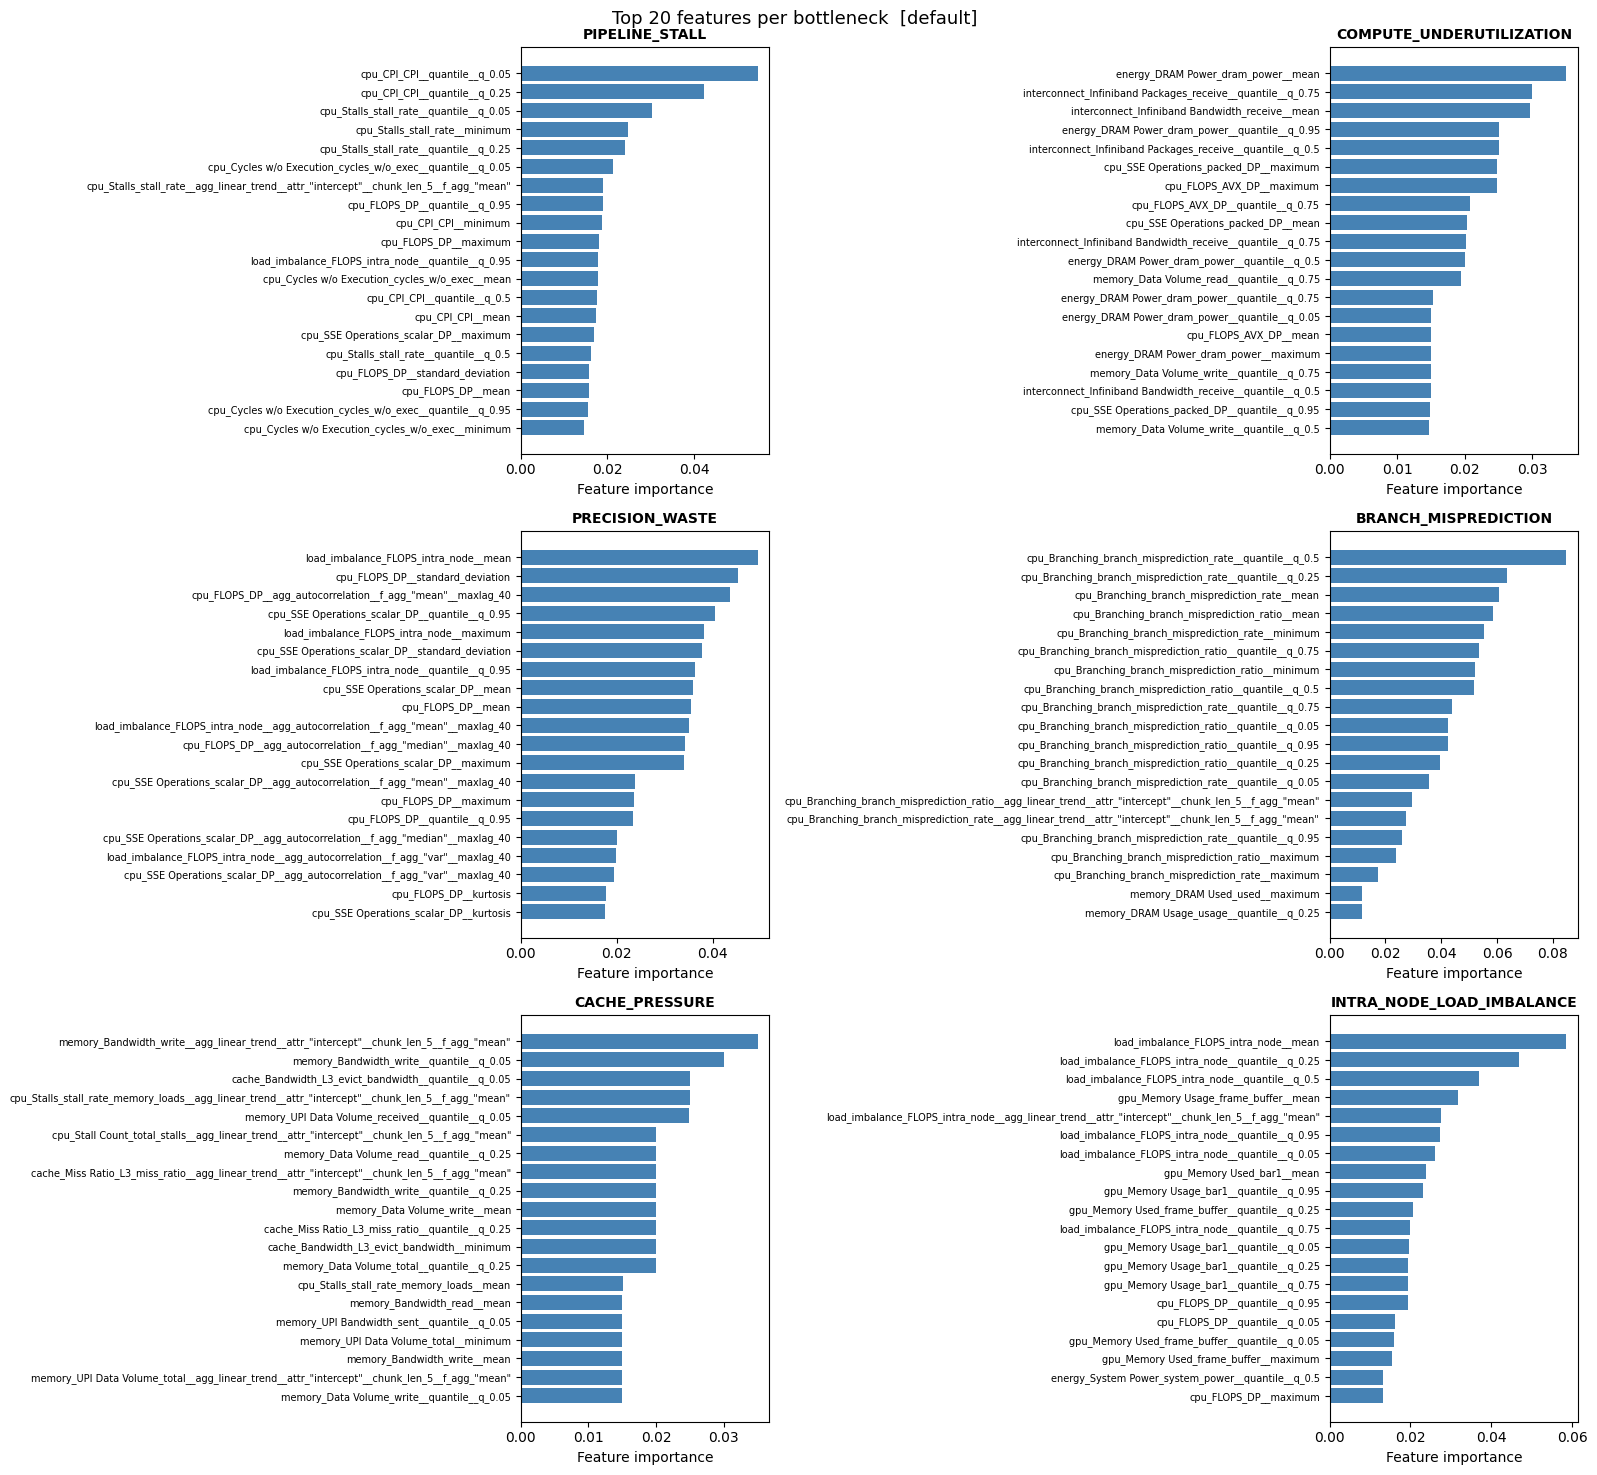

In [25]:
n_bt   = len(importance_by_bt)
n_cols = 2
n_rows = math.ceil(n_bt / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows), squeeze=False)
axes_flat = axes.flatten()

for i, (bt_name, df) in enumerate(importance_by_bt.items()):
    ax  = axes_flat[i]
    top = df.head(TOP_N)
    ax.barh(top["feature"][::-1], top["importance"][::-1], color="steelblue")
    ax.set_title(bt_name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Feature importance")
    ax.tick_params(axis="y", labelsize=7)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(f"Top {TOP_N} features per bottleneck  [{model_name}]", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Global Feature Importance

Aggregated across all bottleneck types.  
`mean_importance` = average over the models that include each feature.  
`n_models` = how many classifiers selected that feature.

In [26]:
all_rows = []
for bt_name, df in importance_by_bt.items():
    tmp = df.copy()
    tmp["bottleneck"] = bt_name
    all_rows.append(tmp)

all_df = pd.concat(all_rows, ignore_index=True)

global_importance = (
    all_df.groupby("feature")["importance"]
    .agg(mean_importance="mean", max_importance="max", n_models="count")
    .reset_index()
    .sort_values("mean_importance", ascending=False)
    .reset_index(drop=True)
)

print(f"Unique features across all models: {len(global_importance)}")
print(f"\nTop {TOP_N} (globally):")
print(global_importance.head(TOP_N).to_string(index=False))
print(f"\nBottom {TOP_N} (globally):")
print(global_importance.tail(TOP_N).to_string(index=False))

Unique features across all models: 1035

Top 20 (globally):
                                                                              feature  mean_importance  max_importance  n_models
                             cpu_Branching_branch_misprediction_rate__quantile__q_0.5         0.028273        0.084819         3
                                                load_imbalance_FLOPS_intra_node__mean         0.023640        0.058542         5
                                        cpu_Branching_branch_misprediction_rate__mean         0.021838        0.060568         3
                                       cpu_Branching_branch_misprediction_ratio__mean         0.021214        0.058643         3
                            cpu_Branching_branch_misprediction_rate__quantile__q_0.25         0.021135        0.063406         3
                                     cpu_Branching_branch_misprediction_rate__minimum         0.020155        0.055464         3
                           cpu_Branch

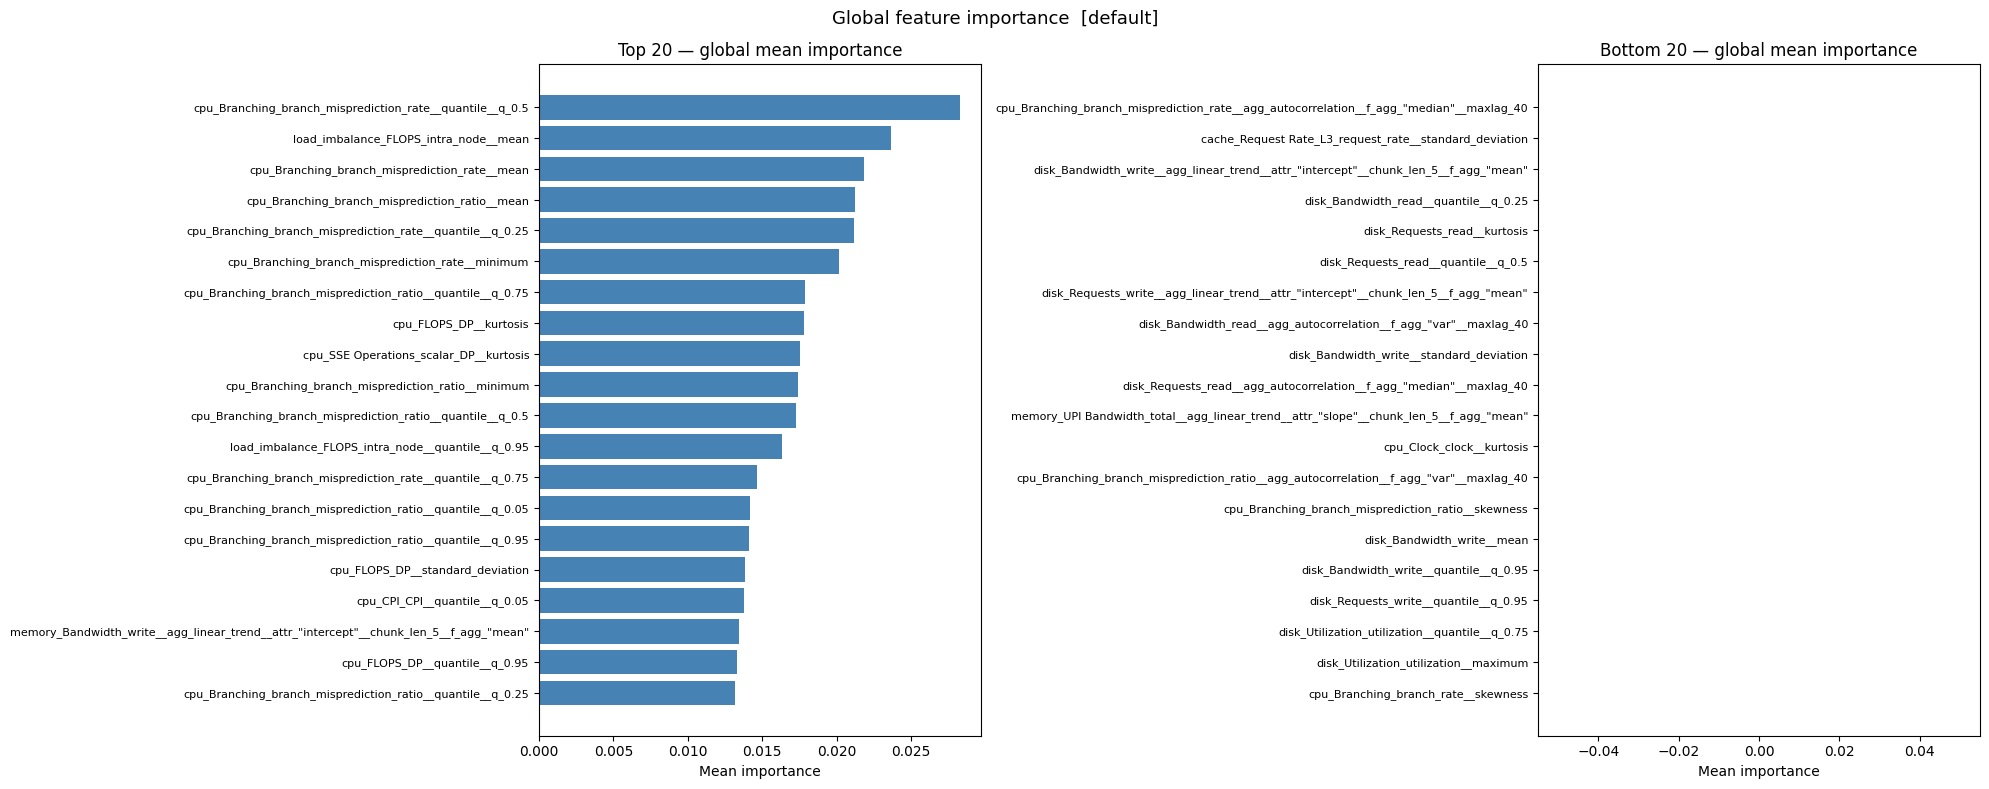

In [27]:
fig, (ax_top, ax_bot) = plt.subplots(1, 2, figsize=(20, 8))

top_g = global_importance.head(TOP_N)
ax_top.barh(top_g["feature"][::-1], top_g["mean_importance"][::-1], color="steelblue")
ax_top.set_title(f"Top {TOP_N} — global mean importance")
ax_top.set_xlabel("Mean importance")
ax_top.tick_params(axis="y", labelsize=8)

bot_g = global_importance.tail(TOP_N)
ax_bot.barh(bot_g["feature"], bot_g["mean_importance"], color="salmon")
ax_bot.set_title(f"Bottom {TOP_N} — global mean importance")
ax_bot.set_xlabel("Mean importance")
ax_bot.tick_params(axis="y", labelsize=8)

plt.suptitle(f"Global feature importance  [{model_name}]", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Importance by tsfresh Statistic

tsfresh feature names follow the pattern `{metric}__{statistic}[__params]`.  
This section groups features by their statistic type and ranks them by mean importance —  
revealing which *kinds* of computation (mean, skewness, autocorrelation, …) the models rely on most.

In [28]:
def _stat_base(feature_name: str) -> str:
    """Statistic family: 'quantile', 'agg_autocorrelation', 'mean', …"""
    parts = feature_name.split("__")
    return parts[1] if len(parts) >= 2 else feature_name

def _stat_full(feature_name: str) -> str:
    """Full spec with params: 'quantile__q_0.05', 'agg_linear_trend__attr_slope__chunk_len_5', …"""
    parts = feature_name.split("__")
    return "__".join(parts[1:]) if len(parts) >= 2 else feature_name

all_df["stat_base"] = all_df["feature"].apply(_stat_base)
all_df["stat_full"] = all_df["feature"].apply(_stat_full)

# High-level: group by statistic family
stat_base_imp = (
    all_df.groupby("stat_base")["importance"]
    .agg(mean_importance="mean", total_importance="sum", n_features="count")
    .reset_index()
    .sort_values("mean_importance", ascending=False)
    .reset_index(drop=True)
)

# Detailed: group by full spec — distinguishes quantile q=0.05 vs q=0.95, etc.
stat_full_imp = (
    all_df.groupby(["stat_base", "stat_full"])["importance"]
    .agg(mean_importance="mean", total_importance="sum", n_features="count")
    .reset_index()
    .sort_values("mean_importance", ascending=False)
    .reset_index(drop=True)
)

print("=== Statistic families (high-level) ===")
print(stat_base_imp.to_string(index=False))
print("\n=== Full statistic specs (with parameters) ===")
print(stat_full_imp.to_string(index=False))

=== Statistic families (high-level) ===
          stat_base  mean_importance  total_importance  n_features
               mean         0.002631          0.894456         340
           quantile         0.001944          3.161323        1626
            maximum         0.001444          0.472181         327
   agg_linear_trend         0.001318          0.523214         397
            minimum         0.001244          0.371891         299
agg_autocorrelation         0.000921          0.311295         338
 standard_deviation         0.000844          0.199129         236
           kurtosis         0.000460          0.044156          96
           skewness         0.000191          0.022354         117

=== Full statistic specs (with parameters) ===
          stat_base                                                     stat_full  mean_importance  total_importance  n_features
               mean                                                          mean         0.002631          0.894

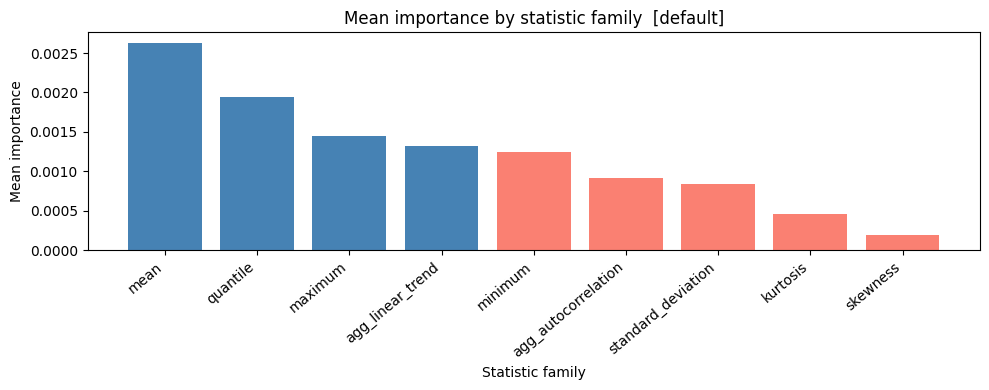

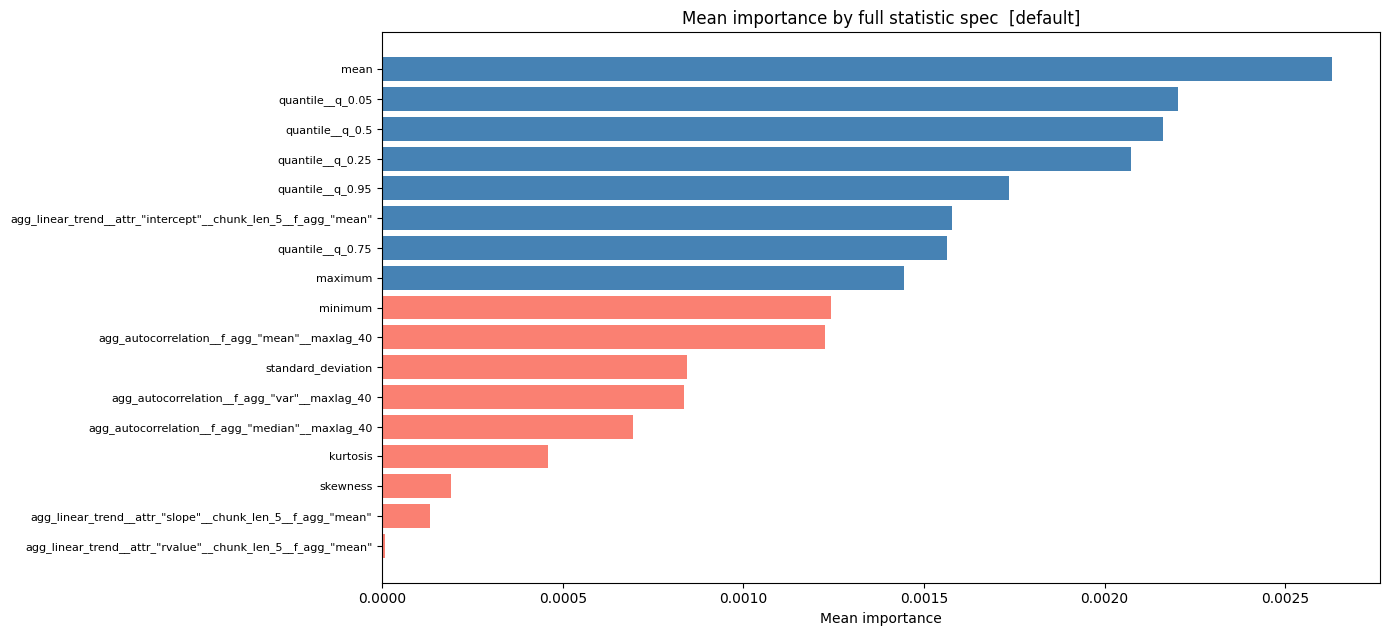

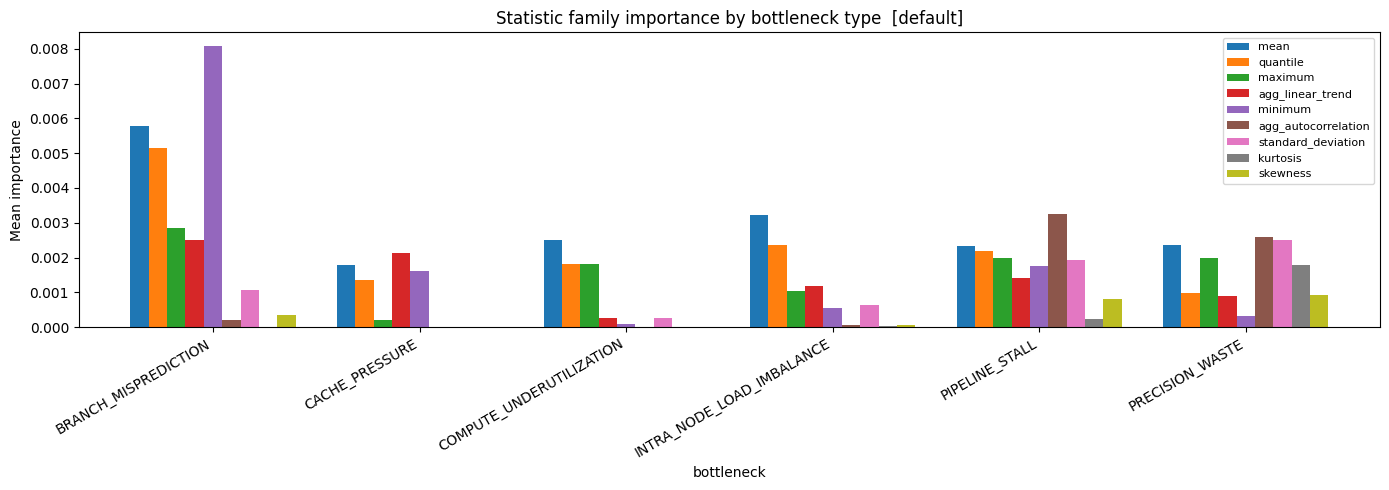

In [29]:
# ── 1. Statistic families (bar chart) ────────────────────────────────────────
n_base  = len(stat_base_imp)
mid     = n_base // 2
colors  = ["steelblue"] * mid + ["salmon"] * (n_base - mid)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(stat_base_imp["stat_base"], stat_base_imp["mean_importance"], color=colors)
ax.set_title(f"Mean importance by statistic family  [{model_name}]")
ax.set_xlabel("Statistic family")
ax.set_ylabel("Mean importance")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

# ── 2. Full specs — shows quantile q=0.05 vs q=0.95, trend slope vs intercept, …
n_full   = len(stat_full_imp)
mid_f    = n_full // 2
colors_f = ["steelblue"] * mid_f + ["salmon"] * (n_full - mid_f)

fig, ax = plt.subplots(figsize=(14, max(5, n_full * 0.38)))
ax.barh(
    stat_full_imp["stat_full"][::-1],
    stat_full_imp["mean_importance"][::-1],
    color=colors_f[::-1],
)
ax.set_title(f"Mean importance by full statistic spec  [{model_name}]")
ax.set_xlabel("Mean importance")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

# ── 3. Per-bottleneck breakdown by family ─────────────────────────────────────
stat_per_bt = (
    all_df.groupby(["bottleneck", "stat_base"])["importance"]
    .mean()
    .unstack(fill_value=0.0)
    .reindex(columns=stat_base_imp["stat_base"])
)

stat_per_bt.plot(
    kind="bar",
    figsize=(14, 5),
    width=0.8,
    title=f"Statistic family importance by bottleneck type  [{model_name}]",
)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean importance")
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 5. Save Results

Each run writes a timestamped JSON snapshot to `RESULTS_DIR`.  
`runs_summary.csv` grows across runs so you can track which model produced which results.

In [30]:
RESULTS_DIR_ABS.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_key   = f"{model_name}_{timestamp}"

results = {
    "run_key"   : run_key,
    "model_path": str(MODEL_PATH_ABS),
    "model_name": model_name,
    "timestamp" : timestamp,
    "per_bottleneck": {
        bt_name: {
            "n_features"     : len(df),
            "top_features"   : df.head(SAVE_N)[["feature", "importance"]].to_dict("records"),
            "bottom_features": df.tail(SAVE_N)[["feature", "importance"]].to_dict("records"),
        }
        for bt_name, df in importance_by_bt.items()
    },
    "global": {
        "top_features"   : global_importance.head(SAVE_N).to_dict("records"),
        "bottom_features": global_importance.tail(SAVE_N).to_dict("records"),
    },
    "statistics": {
        "by_family"   : stat_base_imp.to_dict("records"),
        "by_full_spec": stat_full_imp.to_dict("records"),
    },
}

out_path = RESULTS_DIR_ABS / f"{run_key}.json"
out_path.write_text(json.dumps(results, indent=2))
print(f"Saved  : {out_path}")

# Rolling summary CSV — one row per run
summary_path = RESULTS_DIR_ABS / "runs_summary.csv"
new_row = pd.DataFrame([{
    "run_key"           : run_key,
    "model_name"        : model_name,
    "model_path"        : str(MODEL_PATH_ABS),
    "timestamp"         : timestamp,
    "n_bottleneck_types": len(importance_by_bt),
    "result_file"       : out_path.name,
}])

if summary_path.exists():
    existing = pd.read_csv(summary_path)
    summary  = pd.concat([existing, new_row], ignore_index=True)
else:
    summary = new_row

summary.to_csv(summary_path, index=False)
print(f"Summary: {summary_path}")
print()
print(summary.to_string(index=False))

Saved  : /home/crippius/uni/master-thesis/hpc-bottleneck-detector/models/default_20260424_122353.json
Summary: /home/crippius/uni/master-thesis/hpc-bottleneck-detector/models/runs_summary.csv

                run_key model_name                                                                  model_path       timestamp  n_bottleneck_types                  result_file
default_20260424_120447    default /home/crippius/uni/master-thesis/hpc-bottleneck-detector/models/default.pkl 20260424_120447                   6 default_20260424_120447.json
default_20260424_120551    default /home/crippius/uni/master-thesis/hpc-bottleneck-detector/models/default.pkl 20260424_120551                   6 default_20260424_120551.json
default_20260424_122353    default /home/crippius/uni/master-thesis/hpc-bottleneck-detector/models/default.pkl 20260424_122353                   6 default_20260424_122353.json
